In [1]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing

In [6]:
housing_dataset = fetch_california_housing()
print(housing_dataset.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [7]:
df = pd.DataFrame(housing_dataset.data, columns=housing_dataset.feature_names)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [8]:
df.shape

(20640, 8)

# Creare unui model in Tensorflow

In [28]:
model = tf.keras.models.Sequential([
    ## Layer de INPUT - neschimbat
    tf.keras.layers.Input(shape=(8,)),


    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),



    ## LAYER OUTPUT
     tf.keras.layers.Dense(1),

])

In [29]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [30]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
x = housing_dataset.data
y = housing_dataset.target


x_train, x_test, y_train,  y_test = train_test_split(x, y)

In [31]:
model_result = model.fit(x_train, y_train, epochs=20)

Epoch 1/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 11.5765 - mae: 1.9234
Epoch 2/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 19.5712 - mae: 1.8367
Epoch 3/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.4688 - mae: 1.1109
Epoch 4/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.5303 - mae: 1.4718
Epoch 5/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.4134 - mae: 1.4805
Epoch 6/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 25.3200 - mae: 2.2973
Epoch 7/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.4987 - mae: 0.8602
Epoch 8/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 17.3415 - mae: 1.9569
Epoch 9/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.7039 - mae: 1.3017
Epoch 10/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3470 - mae: 0.8101
Epoch 11/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 6.8854 - mae: 1.4236
Epoch 12/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 2.5642 - mae: 0.9419
Epoch 13/20
484/484 ━

In [22]:
model.evaluate(x_test, y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7215 - mae: 0.6137


[0.7215324640274048, 0.6136806011199951]

In [32]:
model_result.history

{'loss': [11.576525688171387,
  19.57118034362793,
  3.4688289165496826,
  8.530287742614746,
  5.413434982299805,
  25.31998634338379,
  1.4987313747406006,
  17.34150505065918,
  4.703855991363525,
  1.34699547290802,
  6.885404109954834,
  2.564227819442749,
  5.989284038543701,
  20.41863441467285,
  1.4999666213989258,
  8.811272621154785,
  6.961056232452393,
  4.604483127593994,
  1.7978512048721313,
  1.2053422927856445],
 'mae': [1.9233583211898804,
  1.8367189168930054,
  1.1109240055084229,
  1.4717777967453003,
  1.4804620742797852,
  2.2972657680511475,
  0.8601818680763245,
  1.956916093826294,
  1.3017092943191528,
  0.8100802302360535,
  1.4236488342285156,
  0.9418754577636719,
  1.4002782106399536,
  1.8499633073806763,
  0.8637775778770447,
  1.5050019025802612,
  1.435352087020874,
  1.3258068561553955,
  0.932574450969696,
  0.7931368350982666]}

In [33]:
model_history = model_result.history

pd.DataFrame(model_history)

,loss,mae
0,11.576526,1.923358
1,19.571180,1.836719
2,3.468829,1.110924
3,8.530288,1.471778
4,5.413435,1.480462
5,25.319986,2.297266
6,1.498731,0.860182
7,17.341505,1.956916
8,4.703856,1.301709
9,1.346995,0.810080


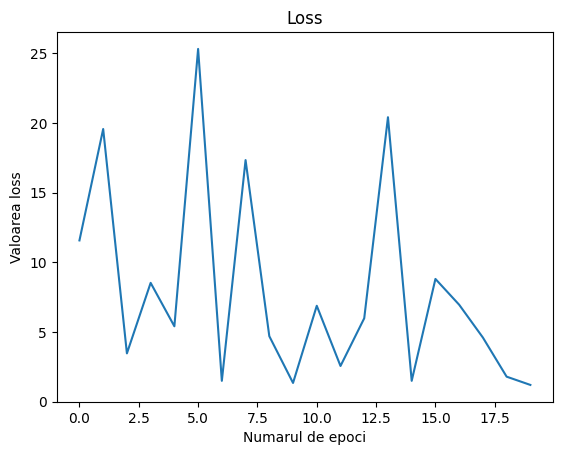

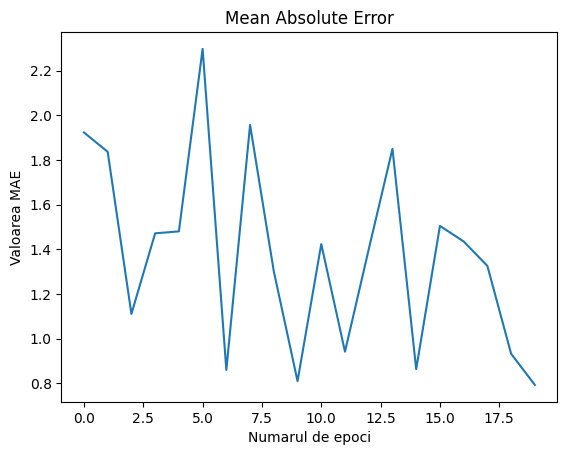

In [35]:
loss = model_history["loss"]
mae = model_history["mae"]

plt.plot(loss)
plt.title("Loss")
plt.xlabel("Numarul de epoci")
plt.ylabel("Valoarea loss")
plt.show()

plt.plot(mae)
plt.title("Mean Absolute Error")
plt.xlabel("Numarul de epoci")
plt.ylabel("Valoarea MAE")
plt.show()


# Ajustari de modele

Epoch 1/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 130.3866 - mae: 3.8506 
Epoch 2/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 10.1414 - mae: 1.4477
Epoch 3/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.8888 - mae: 1.3840
Epoch 4/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5.8054 - mae: 1.3189
Epoch 5/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.5066 - mae: 1.2543
Epoch 6/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.3421 - mae: 1.1596
Epoch 7/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.7263 - mae: 1.0731
Epoch 8/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.3045 - mae: 1.0327
Epoch 9/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.6804 - mae: 0.9297
Epoch 10/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.4158 - mae: 0.8740
Epoch 11/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1399 - mae: 0.8182
Epoch 12/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9632 - mae: 0.7555
Epoch 13/20
484/484 ━

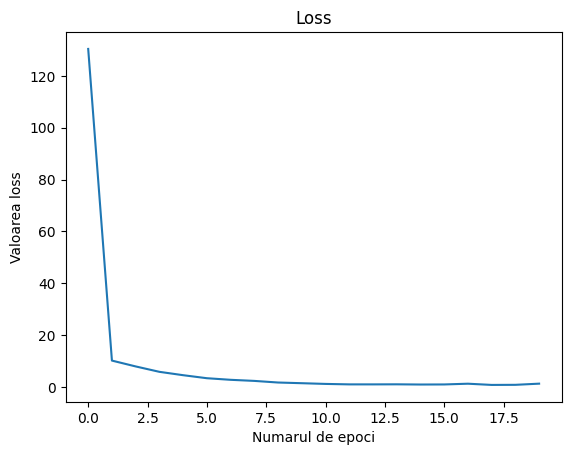

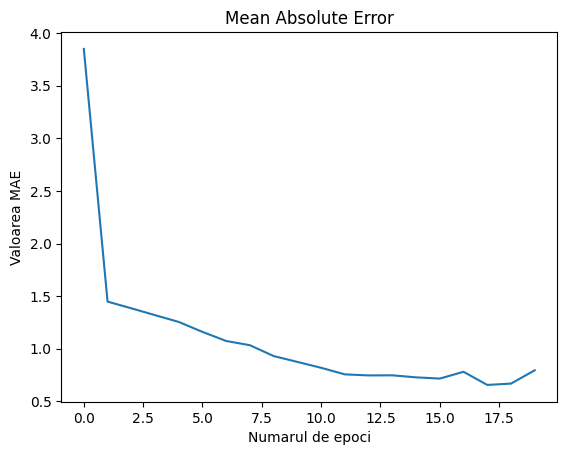

In [37]:
model_2 = tf.keras.models.Sequential([
    ## Layer de INPUT - neschimbat
    tf.keras.layers.Input(shape=(8,)),


    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),



    ## LAYER OUTPUT
     tf.keras.layers.Dense(1),

])

model_2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])

model_result2 = model_2.fit(x_train, y_train, epochs=20)
model_history2 = model_result2.history



loss = model_history2["loss"]
mae = model_history2["mae"]

plt.plot(loss)
plt.title("Loss")
plt.xlabel("Numarul de epoci")
plt.ylabel("Valoarea loss")
plt.show()

plt.plot(mae)
plt.title("Mean Absolute Error")
plt.xlabel("Numarul de epoci")
plt.ylabel("Valoarea MAE")
plt.show()